# Decision Trees and Random Forests
In this task, the datset is analyzed using pairplot, train a single Decision Tree, predict and evaluate the Decision Tree, and compare the Decision Tree model to a Random Forest.
The goal of using a Decision Tree is to create a training model that can be used to predict the class or value of the target variable by using simple decision rules inferred from prior data(training data).

## Import Libraries and Load Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
df = pd.read_csv('heart.csv')

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
print(df['target'].value_counts())

target
1    526
0    499
Name: count, dtype: int64


## Exploratory Data Analysis

C:\Users\ak818\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


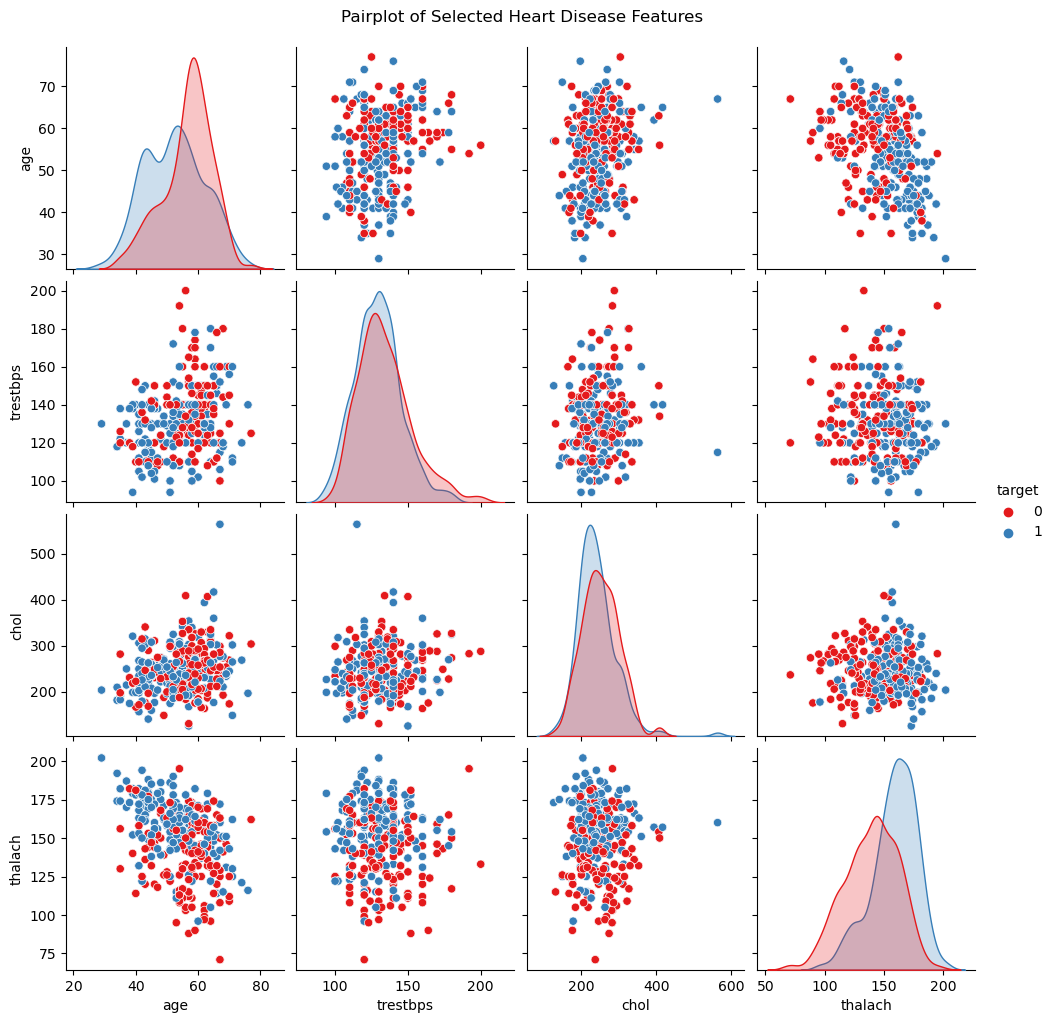

In [8]:
selected_features = ['age', 'trestbps', 'chol', 'thalach', 'target']
sns.pairplot(df[selected_features], hue='target', palette='Set1')
plt.suptitle("Pairplot of Selected Heart Disease Features", y=1.02)
plt.show()

## 1.Train a decision Tree Classifier 

### Train Test Split

Here the dataset is preprocessed to separate the features(X) from the target variable(Y), which indicates whether or not a person has heart disease.

In [15]:
from sklearn.model_selection import train_test_split, cross_val_score
X = df.drop('target',axis=1)
y = df['target']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Decision Tree

After splitting the dataset into training and testing sets, we train a Decision Tree Classifier using Scikit-learn.A decision tree works by learning rules from the data in a hierarchical structure, where each internal node represents a decision based on a feature, and each leaf node represents an output class.

In [21]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## Visualize Decision Tree

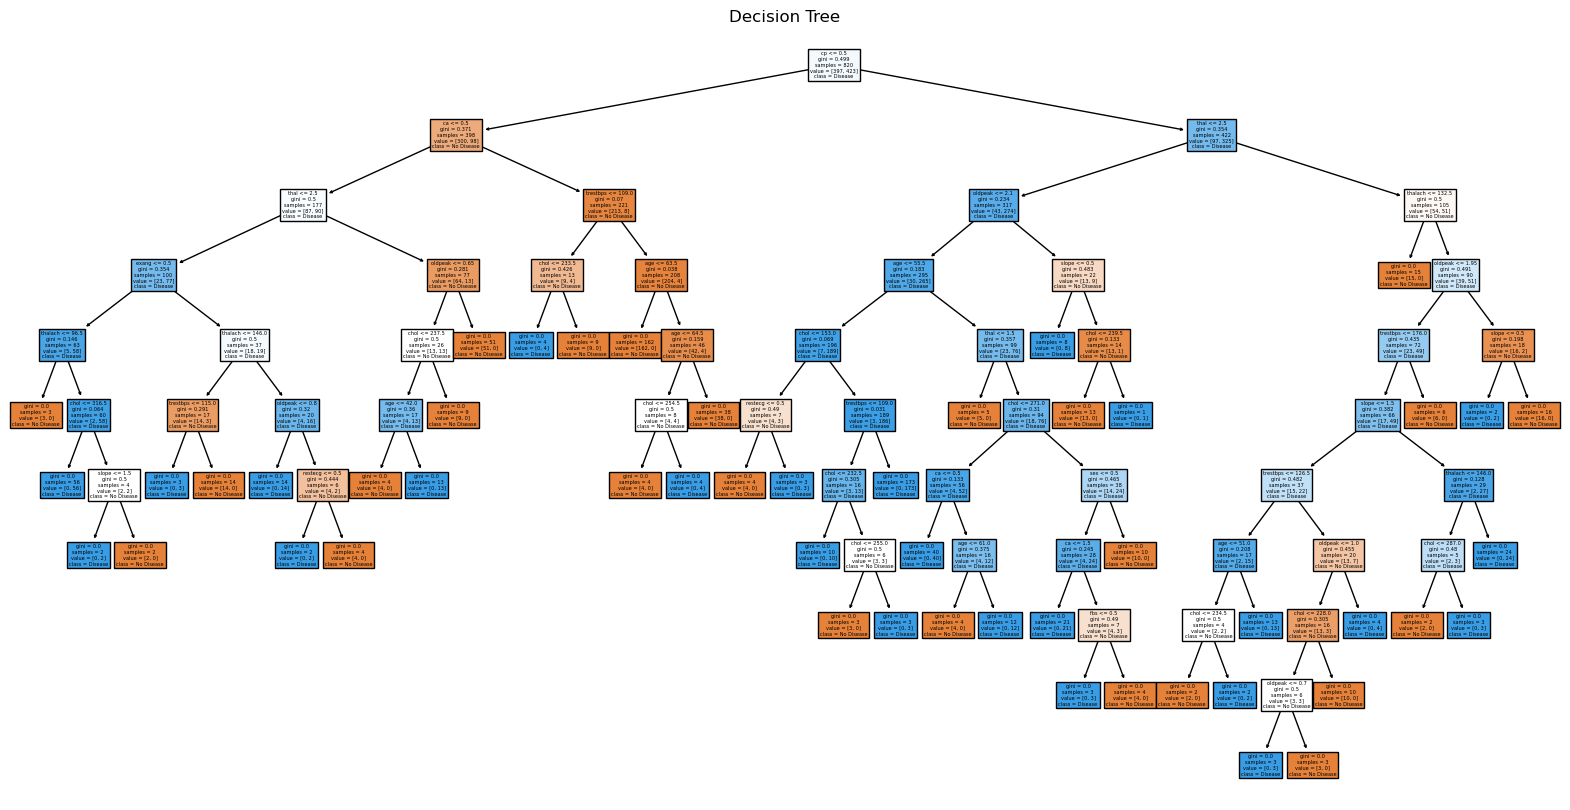

In [27]:
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns.tolist(), class_names=['No Disease', 'Disease'], filled=True)
plt.title("Decision Tree")
plt.show()

## 2.Analyze Overfitting 

Decision trees are prone to overfitting, especially when they are allowed to grow to their full depth without constraints.
To address this, we retrain the decision tree but this time we limit its max_depth to a smaller value 

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [31]:
dt_limited = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_limited.fit(X_train, y_train)
y_pred = dt_limited.predict(X_test)

In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8


In [33]:
print(confusion_matrix(y_test, y_pred))

[[71 31]
 [10 93]]


In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.70      0.78       102
           1       0.75      0.90      0.82       103

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205



## 3. Random Forest

A Random Forest Classifieris trained to improve accuracy, which is a method that builds multiple decision trees and aggregates their predictions. 

In [35]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [36]:
rfc_pred = rfc.predict(X_test)

In [38]:
print(confusion_matrix(y_test,rfc_pred))

[[102   0]
 [  3 100]]


In [39]:
print(classification_report(y_test,rfc_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



## 4. Feature Importance

Once the random forest model is trained, the important features are analyzed which tells how much each feature contributed to the final prediction. Random Forest provides this information by measuring how each feature improves the splitting criterion across all the trees.

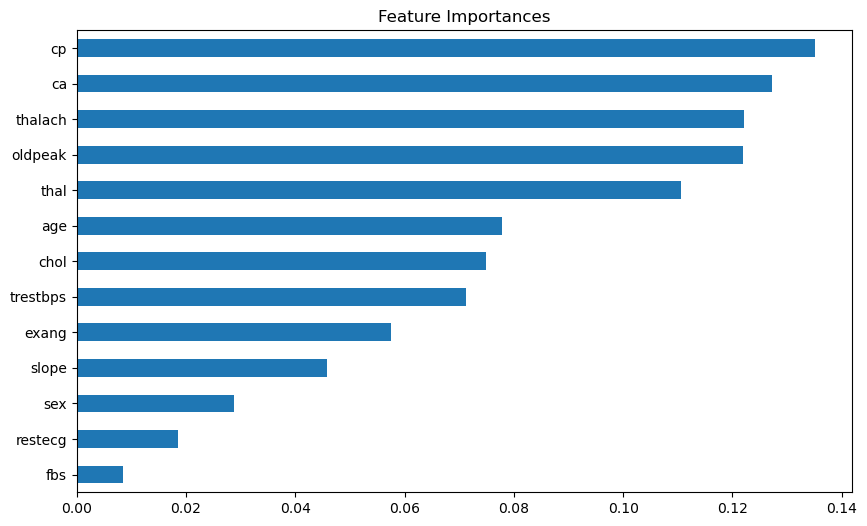

In [41]:
importances = pd.Series(rfc.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10,6), title='Feature Importances')
plt.show()

## 5. Cross Validation

Cross-validation is used to assess model's stability and performance across different data splits.

In [42]:
cv_scores = cross_val_score(rfc, X, y, cv=5)

print("Cross-Validation Scores:", cv_scores)
print("Average CV Score:", np.mean(cv_scores))

Cross-Validation Scores: [1.         1.         1.         1.         0.98536585]
Average CV Score: 0.9970731707317073
